In [ ]:
#import library
!pip install kaggle
import tensorflow as tf
import keras
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#kaggle api
import os

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/access_token', 'w') as f:
    f.write('KGAT_c0f77cb7c2b3f0440b4bf5b11d63991b')  #token

os.chmod('/root/.kaggle/access_token', 600)

In [ ]:
!kaggle datasets list #test koneksi

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          17231        379                1  
sharmajicoder/gen-z-social-media-usage-dataset                      Gen-Z Social Media Usage Dataset                      44185801  2026-04-25 08:23:33.093000           1080         33                1  
mubashirsidiki/student-academic-performance-500-students            Student Academic Performance - 500 Students               6413  2026-04-07 14:23:47.547000           4880         96

In [ ]:
#download tokopedia product riviews
!kaggle datasets download -d salmanabdu/tokopedia-product-reviews-2025

#extract file
!mkdir -p tokopedia
!unzip -o tokopedia-product-reviews-2025.zip -d tokopedia

#load data
df_tokopedia_reviews = pd.read_csv('tokopedia/tokopedia_product_reviews_2025.csv', on_bad_lines='skip', engine='python')
df_tokopedia_reviews.head()

Dataset URL: https://www.kaggle.com/datasets/salmanabdu/tokopedia-product-reviews-2025
License(s): MIT
tokopedia-product-reviews-2025.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  tokopedia-product-reviews-2025.zip
  inflating: tokopedia/tokopedia_product_reviews_2025.csv  


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive


In [ ]:
#download fashion product images
!kaggle datasets download -d paramaggarwal/fashion-product-images-dataset

#extract file
!mkdir -p fashion
!unzip -o fashion-product-images-dataset.zip -d fashion

#load data
df_fashion = pd.read_csv('fashion/fashion-dataset/styles.csv', on_bad_lines='skip', engine='python')
df_fashion.head()

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: fashion/fashion-dataset/styles/58128.json  
  inflating: fashion/fashion-dataset/styles/58129.json  
  inflating: fashion/fashion-dataset/styles/5813.json  
  inflating: fashion/fashion-dataset/styles/58131.json  
  inflating: fashion/fashion-dataset/styles/58132.json  
  inflating: fashion/fashion-dataset/styles/58133.json  
  inflating: fashion/fashion-dataset/styles/58135.json  
  inflating: fashion/fashion-dataset/styles/58136.json  
  inflating: fashion/fashion-dataset/styles/58137.json  
  inflating: fashion/fashion-dataset/styles/58138.json  
  inflating: fashion/fashion-dataset/styles/58139.json  
  inflating: fashion/fashion-dataset/styles/5814.json  
  inflating: fashion/fashion-dataset/styles/58140.json  
  inflating: fashion/fashion-dataset/styles/58141.json  
  inflating: fashion/fashion-dataset/styles/58143.json  
  inflating: fashion/fashion-dataset/styles/58144.json  
  inflating: fashion/fashion-da

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


-> tahap preparatin dataset merupakan langkah awal dalam proses analisis. data teks dan gambar yang dikumpulkan akan digunakan untuk membangun model klarifikasi dan analisis sentimen. kombinasi kedua pendekatan ini memberikan insight yang lebih komprehensif, baik dari sisi visual produk maupun persepsi pelanggan.

In [ ]:
#ambil top 3 kategori terbanyak
tc= df_fashion['articleType'].value_counts().head(3).index
fitltered= df_fashion[df_fashion['articleType'].isin(tc)]

#ambil max 500 perkategori
sampel = fitltered.groupby('articleType').head(500)


In [ ]:
#ambil gambar
images_fashion = 'fashion/fashion-dataset/images'

sampel['image_path'] = sampel['id'].astype(str)+  ".jpg"
sampel = sampel[sampel['image_path'].apply(
    lambda x: os.path.exists(os.path.join(images_fashion,x))
    )]

/tmp/ipykernel_8246/962360431.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sampel['image_path'] = sampel['id'].astype(str)+  ".jpg"


In [ ]:
#rerize
img_size = (64,64)

def load_image(path, label):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img,channels=3)
  img = tf.image.resize(img,img_size)
  return img, label

In [ ]:
#encode
le = LabelEncoder()
sampel['label'] = le.fit_transform(sampel['articleType'])


In [ ]:
#buat dataset
paths = [os.path.join(images_fashion, p) for p in sampel['image_path']]
labels = sampel['label'].values

if len(paths) == 0:
    print("Warning: No valid image paths found. Creating an empty dataset.")
    train_ds = tf.data.Dataset.from_tensor_slices((tf.constant([], dtype=tf.string), tf.constant([], dtype=tf.int32))).batch(32).repeat()
    val_ds = tf.data.Dataset.from_tensor_slices((tf.constant([], dtype=tf.string), tf.constant([], dtype=tf.int32))).batch(32).repeat()
else:
    full_ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    full_ds = full_ds.map(lambda x, y: load_image(x, y), num_parallel_calls=tf.data.AUTOTUNE)

    total_samples = len(sampel)
    train_size = int(0.8 * total_samples)

    train_data_finite = full_ds.take(train_size).cache()
    val_data_finite = full_ds.skip(train_size).cache()

    train_ds = train_data_finite.shuffle(buffer_size=1000).batch(32).repeat()
    val_ds = val_data_finite.batch(32).repeat()

In [ ]:
#train and validation
total_samples = len(sampel)
train_size = int(0.8 * total_samples)


steps_per_epoch_train = train_size // 32
if train_size % 32 != 0:
    steps_per_epoch_train += 1

steps_per_epoch_val = (total_samples - train_size) // 32
if (total_samples - train_size) % 32 != 0:
    steps_per_epoch_val += 1

print(f"Total samples: {total_samples}")
print(f"Training samples: {train_size}, Batches per epoch: {steps_per_epoch_train}")
print(f"Validation samples: {total_samples - train_size}, Batches per epoch: {steps_per_epoch_val}")

Total samples: 1499
Training samples: 1199, Batches per epoch: 38
Validation samples: 300, Batches per epoch: 10


In [ ]:

# CNN
from tensorflow.keras import layers, models

model_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model_cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#train

model_cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_cnn = model_cnn.fit(train_ds,
                    steps_per_epoch=steps_per_epoch_train,
                    validation_data=val_ds,
                    validation_steps=steps_per_epoch_val,
                    epochs=10)

print("History for CNN model:")
print(history_cnn.history)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 58s 942ms/step - accuracy: 0.6831 - loss: 40.8808 - val_accuracy: 0.8033 - val_loss: 0.4238
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.8657 - loss: 0.3255 - val_accuracy: 0.9133 - val_loss: 0.2314
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 188ms/step - accuracy: 0.9133 - loss: 0.1992 - val_accuracy: 0.9033 - val_loss: 0.2287
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.9491 - loss: 0.1217 - val_accuracy: 0.8767 - val_loss: 0.2939
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step - accuracy: 0.9249 - loss: 0.2196 - val_accuracy: 0.9333 - val_loss: 0.1744
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step - accuracy: 0.9450 - loss: 0.1475 - val_accuracy: 0.9100 - val_loss: 0.2732
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 280ms/step - accuracy: 0.9741 - loss: 0.0712 - val_accuracy: 0.9600 - val_loss: 0.1482
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.9741 - loss: 0.0781 - val_accuracy

In [ ]:
#eksperimen b

from tensorflow.keras.applications import MobileNetV2

base_tl = MobileNetV2(
    input_shape=(64, 64, 3),
    include_top=False,
    weights='imagenet'
)

base_tl.trainable = False

/tmp/ipykernel_8246/2748711815.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_tl = MobileNetV2(


In [ ]:
#tambah layer
x = base_tl.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(3, activation='softmax')(x)

model_tl = models.Model(inputs=base_tl.input, outputs=output)

#train
model_tl.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_tl = model_tl.fit(train_ds,
                       steps_per_epoch=steps_per_epoch_train,
                       validation_data = val_ds.take(steps_per_epoch_val),
                       epochs = 10)

print("History for Transfer Learning model:")
print(history_tl.history)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 220ms/step - accuracy: 0.7073 - loss: 0.6777 - val_accuracy: 0.8367 - val_loss: 0.3200
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.8048 - loss: 0.3959 - val_accuracy: 0.8633 - val_loss: 0.2780
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - accuracy: 0.8365 - loss: 0.3473 - val_accuracy: 0.8200 - val_loss: 0.3167
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.8515 - loss: 0.3275 - val_accuracy: 0.8867 - val_loss: 0.2541
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.8774 - loss: 0.2847 - val_accuracy: 0.8500 - val_loss: 0.2687
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - accuracy: 0.8882 - loss: 0.2567 - val_accuracy: 0.9400 - val_loss: 0.1565
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.8924 - loss: 0.2494 - val_accuracy: 0.8600 - val_loss: 0.2460
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - accuracy: 0.8949 - loss: 0.2381 - val_accuracy: 0

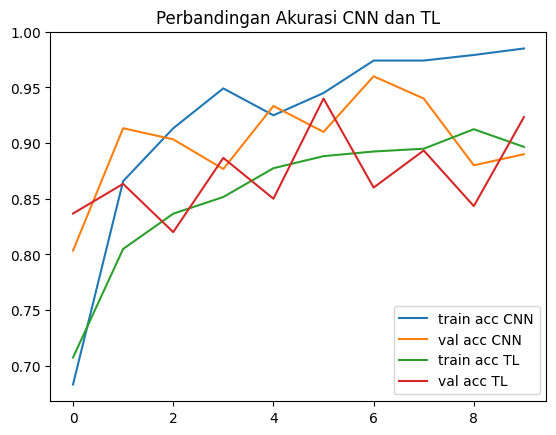

In [ ]:
#visualisasi

#CNN
plt.plot(history_cnn.history['accuracy'], label='train acc CNN')
plt.plot(history_cnn.history['val_accuracy'], label='val acc CNN')

#transfer learning
plt.plot(history_tl.history['accuracy'], label='train acc TL')
plt.plot(history_tl.history['val_accuracy'], label='val acc TL')


plt.legend()
plt.title("Perbandingan Akurasi CNN dan TL")
plt.show()

**interpretasi 1**

-> berdasarkan grafik, model cnn dari nol menunjukkan akurasi training yang sangat tinggi (mendekati 1.0) namun terdapat gap dengan validation accuracy, yang mengindikasikan potensi overfitting. sementara itu, model transfer learning memiliki akurasi yang lebih stabil antara training dan validation meskipun nilainya sedikit lebih rendah. hal ini menunjukkan bahwa transfer learning lebih generalizable, sedangkan cnn dari nol cenderung terlalu menyesuaikan data training.

In [ ]:
df_tokopedia_reviews

,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,baru sekali ini terima brg dr belanja online d...,2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurut...,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
2,Telornya sudah sampai di rumah dengan kemasan ...,2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
3,Telor sudah diterima dengan baik dan tidak ada...,2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik...",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Ome...,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telu...,4601033481,5,1000000,8672687,positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65538,"kwalitas bagus, pokoknya rekomendit deh",2025-01-06,1139605415,SPEEDS Bola Voli Voley Voli Size 5 Volleyball ...,Olahraga,-1 BIRU,68000,https://www.tokopedia.com/speedsofficial/speed...,15686645897,5,90,3851982,positive
65539,Sesuai harga,2025-05-08,1441659919,SPEEDS Bola Voli Voley Voli Size 5 Volleyball ...,Olahraga,NaN,68000,https://www.tokopedia.com/speedsofficial/speed...,15686645897,5,90,3851982,positive
65540,Sesuai harga,2025-05-08,1440420603,SPEEDS Bola Voli Voley Voli Size 5 Volleyball ...,Olahraga,-5 KUNIN,68000,https://www.tokopedia.com/speedsofficial/speed...,15686645897,5,90,3851982,positive
65541,Mantap,2025-02-19,1449641463,SPEEDS Bola Voli Voley Voli Size 5 Volleyball ...,Olahraga,-4 KUNIN,68000,https://www.tokopedia.com/speedsofficial/speed...,15686645897,5,90,3851982,positive


In [ ]:
df_tokopedia_review = df_tokopedia_reviews.sample(10000,random_state=42)
token = Tokenizer(num_words=5000)
token.fit_on_texts(df_tokopedia_reviews['review_text'])

sequences = token.texts_to_sequences(df_tokopedia_reviews['review_text'])
X = pad_sequences(sequences, maxlen=50)

df_tokopedia_reviews['label'] = df_tokopedia_reviews['rating'].apply(lambda x: 1 if x >= 4 else 0)

y = df_tokopedia_reviews['label']

In [ ]:
#split data
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#model LSTM

model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=50),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
#compile
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
    )

In [ ]:
#training dan evaluasi
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
    )
history_lstm = model_lstm.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
    )

Epoch 1/10
1639/1639 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - accuracy: 0.9762 - loss: 0.0849 - val_accuracy: 0.9764 - val_loss: 0.0668
Epoch 2/10
1639/1639 ━━━━━━━━━━━━━━━━━━━━ 63s 39ms/step - accuracy: 0.9822 - loss: 0.0500 - val_accuracy: 0.9777 - val_loss: 0.0665
Epoch 3/10
1639/1639 ━━━━━━━━━━━━━━━━━━━━ 79s 48ms/step - accuracy: 0.9863 - loss: 0.0388 - val_accuracy: 0.9781 - val_loss: 0.0675
Epoch 4/10
1639/1639 ━━━━━━━━━━━━━━━━━━━━ 63s 38ms/step - accuracy: 0.9900 - loss: 0.0295 - val_accuracy: 0.9773 - val_loss: 0.0713


In [ ]:
#evaluasi
loss,acc = model_lstm.evaluate(x_val, y_val)
print("Akurasi:", acc)

410/410 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9777 - loss: 0.0665
Akurasi: 0.9777252078056335


**interpretasi 2**

-> akurasi model mencapei 0.975 yang menunjukkan performa baik. lstm lebih cocok karna mampu memahami urutan dan konteks kata.

In [ ]:
#analisis visual CNN
images_fashion,labels = next(iter(val_ds))

preds = model_cnn.predict(images_fashion)
pred_classes= np.argmax(preds, axis = 1)
true_classes = labels

worng_idx = np.where(pred_classes != true_classes)[0][:3]

plt.figure(figsize=(10, 10))

for i, idx in enumerate(worng_idx):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images_fashion[idx].numpy().astype("uint8"))
    plt.title(f"pred: {pred_classes[idx]}, true: {true_classes[idx]}")
    plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step


<Figure size 1000x1000 with 0 Axes>

In [ ]:
print("Jumlah salah:", len(wrong_idx))

Jumlah salah: 0


**interpretasi 3**

-> model cnn tidak menunjukkan kesalahan pada data validation, yang menandakan performa tinggi. namun, hal ini kemungkinan dipengaruhi overfitting atau data yang terlalu mudah, sehingga belum tentu generalisasi ke data baru baik.

**interpretasi 4**

-> berdasarkan hasil analisis sentimen (lstm), memiliki akurasi lebih tinggi dari pada model visula (cnn), sehingga lebih dapat diandalkan untuk memahami keputusan pelanggan. tim disarankan memanfaatkan analisis ulasan untuk mendeteksi masalah produk secara cepat, serta meningkatkan kualitas gambar produk agar peforma model klebih optimal. kombinasi keduanya dapat membantu meningkatkan kualitas katalog dan pengalaman pelanggan.